In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)



In [36]:
# Load a CSV file
df = pd.read_csv('/content/sample_data/SuperMarket Analysis.csv')

In [7]:
df_copy = df.copy()

In [37]:
df_copy.head()

,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross income,Rating,Hour,Part_of_Day
0,Alex,Yangon,1,0,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,13:08,Ewallet,522.83,26.1415,9.1,13,Afternoon
1,Giza,Naypyitaw,0,0,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29,Cash,76.40,3.8200,9.6,10,Morning
2,Alex,Yangon,0,0,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,13:23,Credit card,324.31,16.2155,7.4,13,Afternoon
3,Alex,Yangon,1,0,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,20:33,Ewallet,465.76,23.2880,8.4,20,Evening
4,Alex,Yangon,1,0,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37,Ewallet,604.17,30.2085,5.3,10,Morning


In [9]:
df_copy.sample(10)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
863,533-66-5566,Cairo,Mandalay,Normal,Female,Home and lifestyle,51.07,7,17.8745,375.3645,1/12/2019,11:42:00 AM,Cash,357.49,4.761905,17.8745,7.0
136,700-81-1757,Alex,Yangon,Normal,Female,Electronic accessories,26.31,5,6.5775,138.1275,1/18/2019,8:59:00 PM,Credit card,131.55,4.761905,6.5775,8.8
731,635-28-5728,Alex,Yangon,Normal,Male,Health and beauty,56.00,3,8.4000,176.4000,2/28/2019,7:33:00 PM,Ewallet,168.00,4.761905,8.4000,4.8
491,510-09-5628,Alex,Yangon,Member,Female,Fashion accessories,19.66,10,9.8300,206.4300,3/15/2019,6:20:00 PM,Credit card,196.60,4.761905,9.8300,7.2
904,545-07-8534,Giza,Naypyitaw,Normal,Female,Health and beauty,58.32,2,5.8320,122.4720,2/14/2019,12:42:00 PM,Ewallet,116.64,4.761905,5.8320,6.0
925,226-34-0034,Cairo,Mandalay,Normal,Female,Electronic accessories,13.78,4,2.7560,57.8760,1/10/2019,11:10:00 AM,Ewallet,55.12,4.761905,2.7560,9.0
813,674-56-6360,Alex,Yangon,Normal,Male,Electronic accessories,95.15,1,4.7575,99.9075,3/22/2019,2:00:00 PM,Cash,95.15,4.761905,4.7575,6.0
206,672-51-8681,Giza,Naypyitaw,Member,Female,Electronic accessories,66.65,9,29.9925,629.8425,1/4/2019,6:19:00 PM,Credit card,599.85,4.761905,29.9925,9.7
969,214-30-2776,Cairo,Mandalay,Member,Female,Electronic accessories,34.49,5,8.6225,181.0725,3/11/2019,7:44:00 PM,Credit card,172.45,4.761905,8.6225,9.0
215,802-43-8934,Alex,Yangon,Normal,Male,Home and lifestyle,18.28,1,0.9140,19.1940,3/22/2019,3:05:00 PM,Credit card,18.28,4.761905,0.9140,8.3


In [10]:
print("Shape:", df_copy.shape)

print("\nColumns:")
print(df_copy.columns)

df_copy.info()

Shape: (1000, 17)

Columns:
Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales   

In [11]:
# 5. Missing Values

df_copy.isnull().sum()

,0
Invoice ID,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,0
Tax 5%,0
Sales,0


In [12]:
# 7. Remove Unnecessary Columns

df_copy.drop(columns=['Invoice ID','gross margin percentage'],inplace=True)
df_copy.head()

#Invoice ID was removed because it is only an identifier.
#Gross Margin Percentage was removed because it contains a constant value and provides no analytical value.

,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross income,Rating
0,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,26.1415,9.1
1,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,3.8200,9.6
2,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,16.2155,7.4
3,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,23.2880,8.4
4,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,30.2085,5.3


In [13]:
print(df.columns.tolist())
print(df_copy.columns.tolist())

['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date', 'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income', 'Rating']
['Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date', 'Time', 'Payment', 'cogs', 'gross income', 'Rating']


In [14]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Branch         1000 non-null   object 
 1   City           1000 non-null   object 
 2   Customer type  1000 non-null   object 
 3   Gender         1000 non-null   object 
 4   Product line   1000 non-null   object 
 5   Unit price     1000 non-null   float64
 6   Quantity       1000 non-null   int64  
 7   Tax 5%         1000 non-null   float64
 8   Sales          1000 non-null   float64
 9   Date           1000 non-null   object 
 10  Time           1000 non-null   object 
 11  Payment        1000 non-null   object 
 12  cogs           1000 non-null   float64
 13  gross income   1000 non-null   float64
 14  Rating         1000 non-null   float64
dtypes: float64(6), int64(1), object(8)
memory usage: 117.3+ KB


In [15]:
# 8. Convert Date & Time

df_copy['Date'] = pd.to_datetime(df_copy['Date'])

df_copy['Time'] = pd.to_datetime(df_copy['Time'])
df_copy['Time'] = df_copy['Time'].dt.strftime('%H:%M')
#Convert the Time column into a 24-hour format for consistency and easier analysis.

/tmp/ipykernel_3836/1820616814.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_copy['Time'] = pd.to_datetime(df_copy['Time'])


In [16]:
# Create Hour Feature
df_copy['Hour'] = pd.to_datetime(df_copy['Time'],format='%H:%M').dt.hour

In [17]:
# Create Part_of_Day Feature
def period(hour):
    if hour < 12:
        return 'Morning'
    elif hour < 17:
        return 'Afternoon'
    else:
        return 'Evening'
df_copy['Part_of_Day'] = df_copy['Hour'].apply(period)

In [18]:
# Convert Gender to 0 and 1
df_copy['Gender'] = df['Gender']

df_copy['Gender'] = df_copy['Gender'].replace({
    'Male': 1,
    'Female': 0
})

/tmp/ipykernel_3836/3212918853.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_copy['Gender'] = df_copy['Gender'].replace({


In [19]:
print(df_copy['Gender'].dtype)
print(df_copy['Gender'].unique())

int64
[0 1]


In [20]:
# Convert Customer Type to 0 and 1
df_copy['Customer type'] = df['Customer type']

df_copy['Customer type'] = df_copy['Customer type'].replace({
    'Member': 1,
    'Normal': 0
})

/tmp/ipykernel_3836/3579492229.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_copy['Customer type'] = df_copy['Customer type'].replace({


In [21]:
print(df_copy['Customer type'].dtype)
print(df_copy['Customer type'].unique())

int64
[1 0]


In [22]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Branch         1000 non-null   object        
 1   City           1000 non-null   object        
 2   Customer type  1000 non-null   int64         
 3   Gender         1000 non-null   int64         
 4   Product line   1000 non-null   object        
 5   Unit price     1000 non-null   float64       
 6   Quantity       1000 non-null   int64         
 7   Tax 5%         1000 non-null   float64       
 8   Sales          1000 non-null   float64       
 9   Date           1000 non-null   datetime64[ns]
 10  Time           1000 non-null   object        
 11  Payment        1000 non-null   object        
 12  cogs           1000 non-null   float64       
 13  gross income   1000 non-null   float64       
 14  Rating         1000 non-null   float64       
 15  Hour           1000 no

In [23]:
df_copy.head()

,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross income,Rating,Hour,Part_of_Day
0,Alex,Yangon,1,0,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,13:08,Ewallet,522.83,26.1415,9.1,13,Afternoon
1,Giza,Naypyitaw,0,0,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29,Cash,76.40,3.8200,9.6,10,Morning
2,Alex,Yangon,0,0,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,13:23,Credit card,324.31,16.2155,7.4,13,Afternoon
3,Alex,Yangon,1,0,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,20:33,Ewallet,465.76,23.2880,8.4,20,Evening
4,Alex,Yangon,1,0,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37,Ewallet,604.17,30.2085,5.3,10,Morning


/tmp/ipykernel_3836/3335490560.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_copy,x='Product line',y='Sales',estimator=sum,palette='viridis')


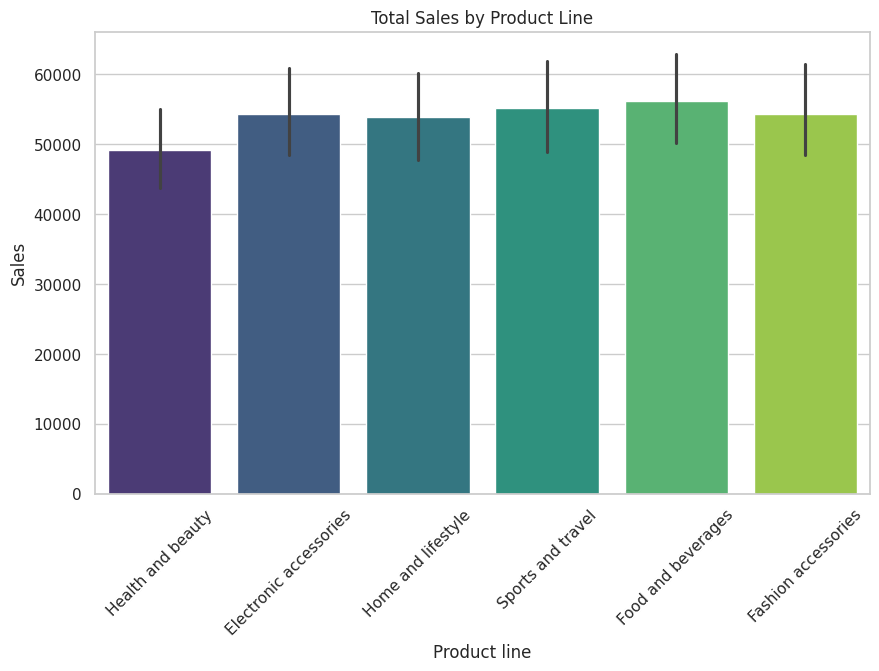

In [24]:
#Total Sales by Product Line
plt.figure()
sns.barplot(data=df_copy,x='Product line',y='Sales',estimator=sum,palette='viridis')
plt.title('Total Sales by Product Line')
plt.xticks(rotation=45)
plt.show()

Insight:
Identify the product category generating the highest revenue.

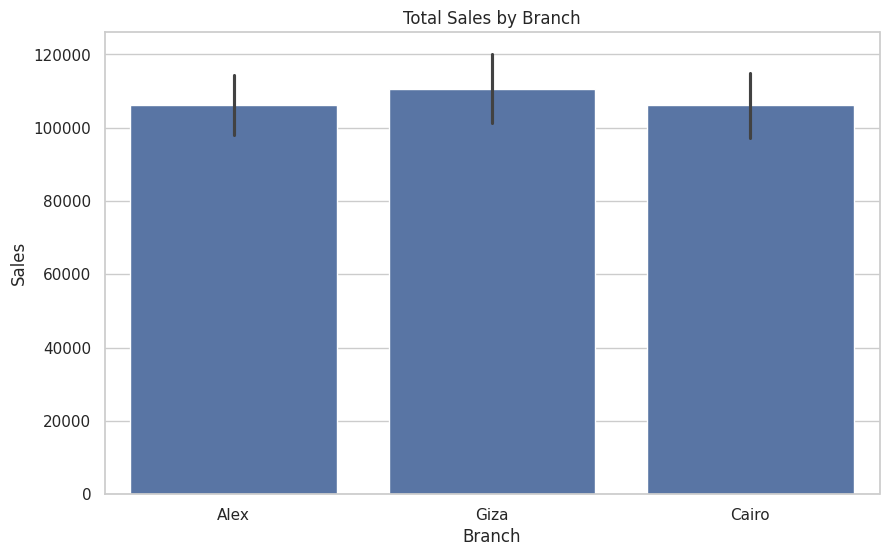

In [25]:
#Sales by Branch
plt.figure()
sns.barplot(data=df_copy,x='Branch',y='Sales',estimator=sum)
plt.title('Total Sales by Branch')
plt.show()

Insight:
Compare branch performance and identify the most profitable branch.

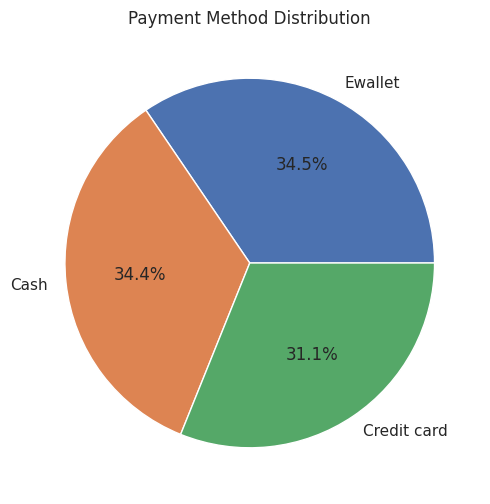

In [34]:
#Payment Method Distribution
payment_counts = df_copy['Payment'].value_counts()
plt.figure()
plt.pie(payment_counts,labels=payment_counts.index,autopct='%1.1f%%')
plt.title('Payment Method Distribution')
plt.show()

Insight:
Determine the most preferred payment method among customers.

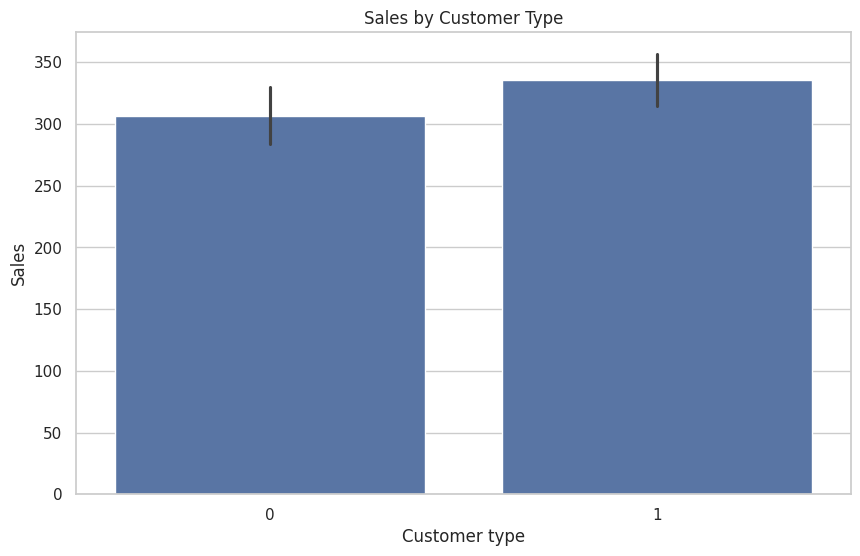

In [27]:
#Sales by Customer Type
plt.figure()
sns.barplot(data=df_copy,x='Customer type', y='Sales')
plt.title('Sales by Customer Type')
plt.show()

Insight:
Compare spending behavior between members and regular customers.

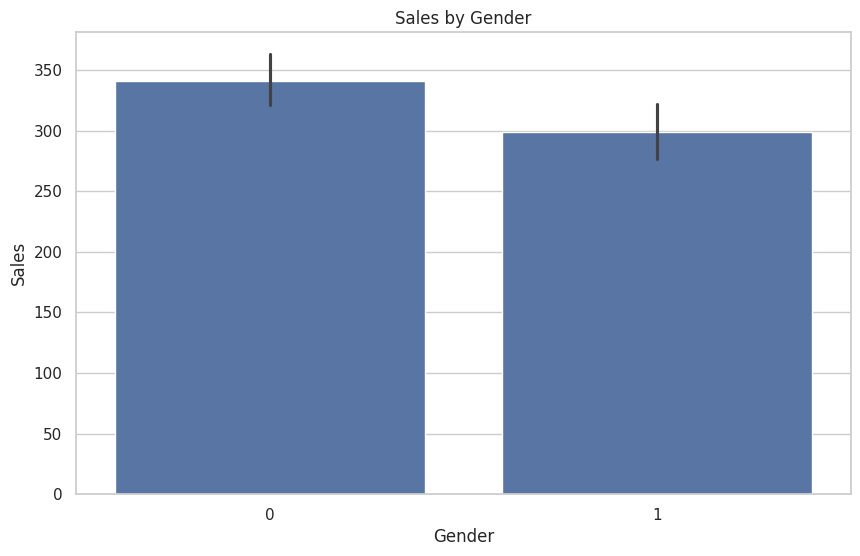

In [28]:
#Sales by Gender
plt.figure()
sns.barplot(data=df_copy,x='Gender',y='Sales')
plt.title('Sales by Gender')
plt.show()

Insight:
Analyze whether purchasing behavior differs by gender.

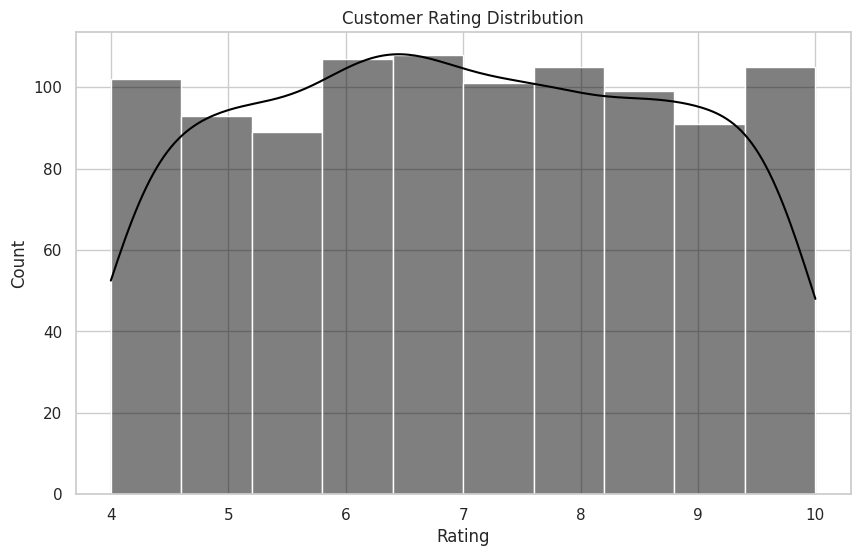

In [29]:
#Customer Rating Distribution
plt.figure()
sns.histplot(df_copy['Rating'],bins=10,color='black',kde=True)
plt.title('Customer Rating Distribution')
plt.show()

Insight:
Evaluate overall customer satisfaction levels.

/tmp/ipykernel_3836/2684709766.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_copy,x='Part_of_Day',y='Sales',estimator=sum,palette='magma')


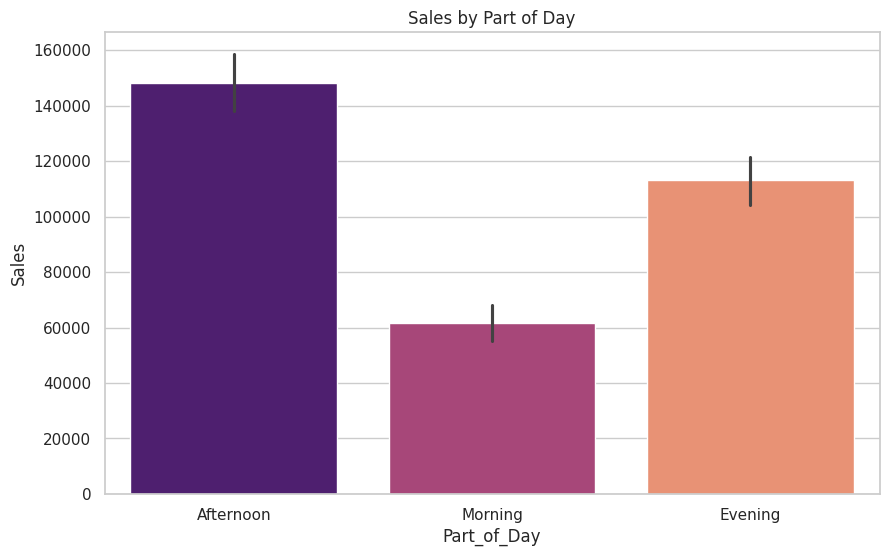

In [30]:
#Sales by Part of Day
sns.barplot(data=df_copy,x='Part_of_Day',y='Sales',estimator=sum,palette='magma')
plt.title('Sales by Part of Day')
plt.show()

Insight:
Determine whether sales peak during the morning, afternoon, or evening.

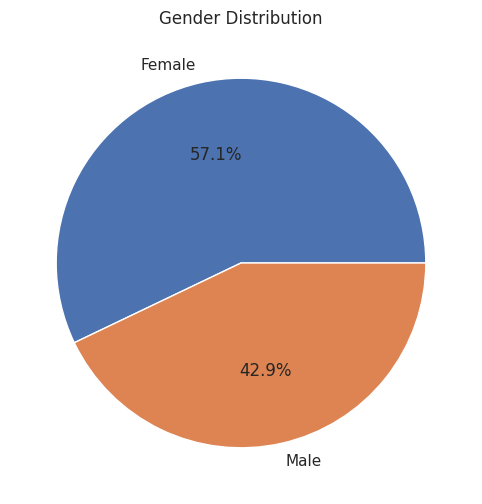

In [31]:
#Gender Distribution
gender_counts = df['Gender'].value_counts()
plt.figure()
plt.pie(gender_counts,labels=gender_counts.index,autopct='%1.1f%%')
plt.title('Gender Distribution')
plt.show()

Insight: Female customers make up a larger proportion of the customer base compared to male customers.

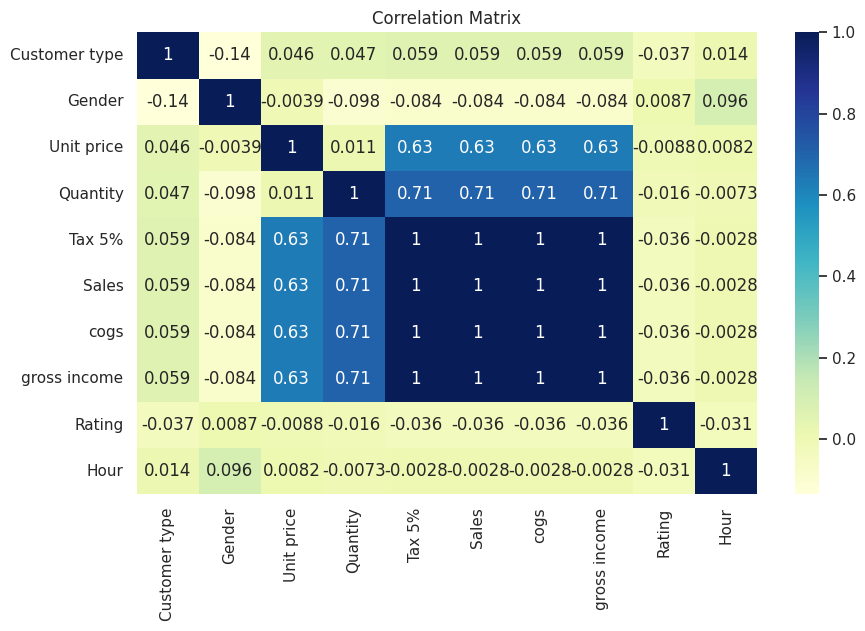

In [32]:
#Correlation Matrix
plt.figure()
sns.heatmap(df_copy.select_dtypes(include='number').corr(),annot=True,cmap='YlGnBu')
plt.title('Correlation Matrix')
plt.show()

Analyze the relationships between numerical variables using a correlation matrix.

In [38]:
%%writefile app.py

import streamlit as st
import pandas as pd

df = pd.read_csv("/content/sample_data/SuperMarket Analysis.csv")

st.title("Supermarket Sales Dashboard")

st.dataframe(df.head())

Writing app.py


In [39]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 77.6 MB/s eta 0:00:00


In [40]:
!streamlit run app.py &>/content/logs.txt &